# Social Media Sentiment Analysis
Classification model with confusion matrix and F1 scores by day, week, and month.

# Import Required Libraries
Import necessary libraries for data processing, model building, and visualization.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


# Load the Dataset
Load the Social Media Sentiments Analysis dataset from CSV file.

In [2]:
# Load the Dataset
# UPDATE THIS PATH if your file has a different name
df = pd.read_csv('sentimentdataset.csv')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset loaded successfully!
Dataset shape: (732, 15)

Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


# Explore the Dataset
Display dataset info, sample rows, and sentiment distribution.

In [3]:
# Explore the Dataset
print("First 5 rows:")
display(df.head())

print("\nDataset Info:")
print(df.info())

print("\nSentiment Distribution:")
print(df['Sentiment'].value_counts())

First 5 rows:


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB
None

Sentiment Distribution:
Sentiment
Positive           44
Joy                42
Ex

# Data Preprocessing
Clean data, parse timestamps, and prepare features for classification.

In [4]:
# Data Preprocessing
# Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

# Clean the Sentiment column (strip whitespace)
df['Sentiment'] = df['Sentiment'].str.strip()

# Define sentiment categories
POSITIVE = [
    'Positive', 'Joy', 'Excitement', 'Contentment', 'Gratitude', 'Happiness', 'Happy',
    'Love', 'Enthusiasm', 'Euphoria', 'Elation', 'Ecstasy', 'Admiration', 'Adoration',
    'Affection', 'Amazement', 'Amusement', 'Appreciation', 'Awe', 'Blessed', 'Calmness',
    'Captivation', 'Celebration', 'Charm', 'Compassion', 'Compassionate', 'Confidence',
    'Confident', 'Connection', 'Coziness', 'Creativity', 'Dazzle', 'Determination',
    'Empowerment', 'Enchantment', 'Energy', 'Engagement', 'Enjoyment', 'Exploration',
    'Freedom', 'Friendship', 'Fulfillment', 'Grandeur', 'Grateful', 'Harmony',
    'Heartwarming', 'Hope', 'Hopeful', 'Imagination', 'Inspiration', 'Inspired',
    'Intrigue', 'Kindness', 'Kind', 'Marvel', 'Mesmerizing', 'Mindfulness', 'Motivation',
    'Optimism', 'Overjoyed', 'Playful', 'Positivity', 'Pride', 'Proud', 'Radiance',
    'Rejuvenation', 'Relief', 'Resilience', 'Reverence', 'Romance', 'Satisfaction',
    'Serenity', 'Spark', 'Success', 'Surprise', 'Sympathy', 'Tenderness', 'Thrill',
    'Touched', 'Tranquility', 'Triumph', 'Vibrancy', 'Whimsy', 'Wonder', 'Wonderment',
    'Zest', 'Acceptance', 'Accomplishment', 'Adventure', 'Adrenaline', 'ArtisticBurst',
    'Breakthrough', 'Celestial Wonder', 'Colorful', 'Creative Inspiration', 'CulinaryOdyssey',
    'Culinary Adventure', 'DreamChaser', 'Elegance', 'FestiveJoy', 'Free-spirited',
    'Hypnotic', 'Iconic', 'Immersion', 'InnerJourney', 'Journey', 'Joy in Baking',
    'JoyfulReunion', 'Melodic', "Nature's Beauty", "Ocean's Freedom", 'PlayfulJoy',
    'Renewed Effort', 'Runway Creativity', 'Solace', 'Thrilling Journey', 'Winter Magic',
    'Whispers of the Past', 'Envisioning History', 'Arousal', 'Mischievous'
]

NEGATIVE = [
    'Negative', 'Anger', 'Anxiety', 'Fear', 'Fearful', 'Sadness', 'Sad', 'Despair',
    'Desperation', 'Devastated', 'Disappointment', 'Disappointed', 'Disgust', 'Frustration',
    'Frustrated', 'Grief', 'Hate', 'Heartache', 'Heartbreak', 'Helplessness', 'Isolation',
    'Jealousy', 'Jealous', 'Loneliness', 'Loss', 'Melancholy', 'Resentment', 'Shame',
    'Sorrow', 'Suffering', 'Betrayal', 'Bitter', 'Bitterness', 'Darkness', 'Desolation',
    'Embarrassed', 'EmotionalStorm', 'Envious', 'Envy', 'Exhaustion', 'Intimidation',
    'LostLove', 'Numbness', 'Overwhelmed', 'Pressure', 'Regret', 'Ruins', 'Bad',
    'Apprehensive', 'Dismissive'
]

NEUTRAL = [
    'Neutral', 'Ambivalence', 'Anticipation', 'Boredom', 'Confusion', 'Contemplation',
    'Curiosity', 'Indifference', 'Nostalgia', 'Pensive', 'Reflection', 'Solitude',
    'Suspense', 'Yearning', 'Bittersweet', 'Challenge', 'Emotion', 'Empathetic',
    'Miscalculation', 'Obstacle'
]

def categorize_sentiment(sentiment):
    sentiment = sentiment.strip()
    if sentiment in POSITIVE:
        return 'Positive'
    elif sentiment in NEGATIVE:
        return 'Negative'
    elif sentiment in NEUTRAL:
        return 'Neutral'
    else:
        sentiment_lower = sentiment.lower()
        neg_keywords = ['sad', 'anger', 'fear', 'hate', 'bad', 'negative', 'pain', 'hurt', 'loss', 'grief']
        pos_keywords = ['joy', 'happy', 'love', 'good', 'positive', 'excite', 'hope', 'peace', 'calm']
        for kw in neg_keywords:
            if kw in sentiment_lower:
                return 'Negative'
        for kw in pos_keywords:
            if kw in sentiment_lower:
                return 'Positive'
        return 'Neutral'

# Map original sentiments to 3 categories
df['Original_Sentiment'] = df['Sentiment']
df['Sentiment'] = df['Original_Sentiment'].apply(categorize_sentiment)

print(f"Sentiment distribution (3 categories):")
print(df['Sentiment'].value_counts())

# Parse timestamp and create date components
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Date'] = df['Timestamp'].dt.date
    df['Year'] = df['Timestamp'].dt.year
    df['Month'] = df['Timestamp'].dt.month
    df['Week'] = df['Timestamp'].dt.isocalendar().week
    df['Day'] = df['Timestamp'].dt.day
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

# Remove rows with missing text or sentiment
df = df.dropna(subset=['Text', 'Sentiment'])

# Get unique sentiments
sentiment_classes = df['Sentiment'].unique()
print(f"\nSentiment classes: {sentiment_classes}")

# Encode sentiment labels
label_encoder = LabelEncoder()
df['sentiment_label'] = label_encoder.fit_transform(df['Sentiment'])

print(f"\nProcessed dataset shape: {df.shape}")

Sentiment distribution (3 categories):
Sentiment
Positive    461
Negative    179
Neutral      92
Name: count, dtype: int64

Sentiment classes: ['Positive' 'Negative' 'Neutral']

Processed dataset shape: (732, 20)


# Feature Engineering
Convert text to TF-IDF features for model training.

In [6]:
# Feature Engineering - TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X = tfidf.fit_transform(df['Text'].astype(str))
y = df['sentiment_label']

print(f"TF-IDF features shape: {X.shape}")
print(f"Target shape: {y.shape}")

TF-IDF features shape: (732, 5000)
Target shape: (732,)


# Split Data into Training and Test Sets
Use train_test_split with stratification to ensure balanced class distribution.

In [7]:
# Split Data into Training and Test Sets
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 585
Test set size: 147


# Build and Train Classification Model
Create a RandomForestClassifier and fit it on the training data.

In [8]:
# Build and Train Classification Model
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Model: {model.__class__.__name__}")

Model trained successfully!
Model: RandomForestClassifier


# Make Predictions on Test Set
Use the trained model to predict sentiment labels for the test set.

In [9]:
# Make Predictions on Test Set
y_pred = model.predict(X_test)

print("Predictions completed!")
print(f"Number of predictions: {len(y_pred)}")

Predictions completed!
Number of predictions: 147


# Evaluate Model Performance
Calculate accuracy, display confusion matrix, and print classification report.

In [10]:
# Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
target_names = label_encoder.classes_
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

Accuracy: 0.7687

Confusion Matrix:
[[15  0 21]
 [ 1  5 12]
 [ 0  0 93]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.42      0.58        36
     Neutral       1.00      0.28      0.43        18
    Positive       0.74      1.00      0.85        93

    accuracy                           0.77       147
   macro avg       0.89      0.56      0.62       147
weighted avg       0.82      0.77      0.73       147



# Confusion Matrix Visualization
Create a heatmap visualization of the confusion matrix.

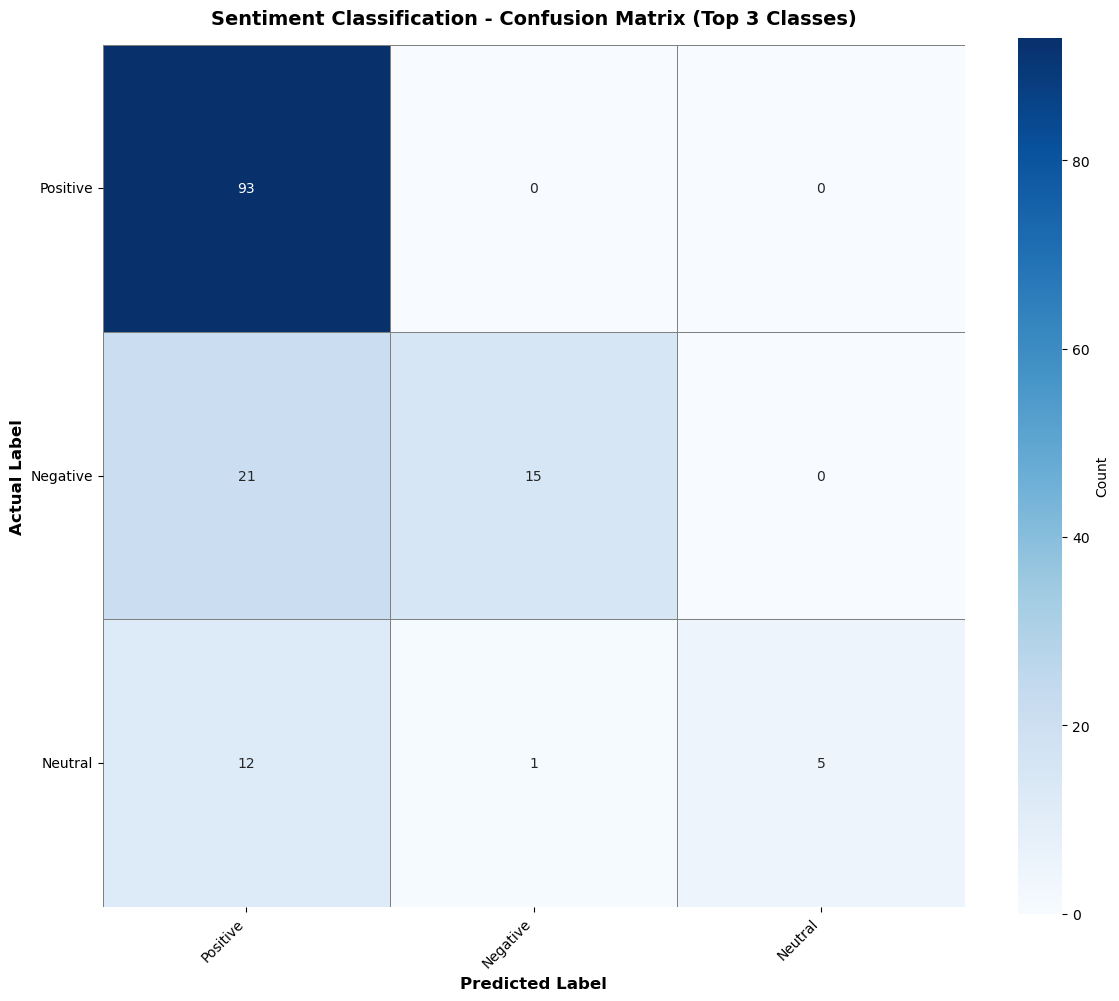

In [11]:
# Confusion Matrix Visualization
# For many classes, show top N most common
top_n = min(15, len(target_names))  # Limit for readability

# Get indices of top N most frequent classes
class_counts = pd.Series(y_test).value_counts()
top_classes = class_counts.head(top_n).index.tolist()

# Filter confusion matrix for top classes
cm_filtered = cm[np.ix_(top_classes, top_classes)]
top_class_names = [target_names[i] for i in top_classes]

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Create heatmap
sns.heatmap(cm_filtered, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_class_names, yticklabels=top_class_names,
            square=True, linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Count'}, ax=ax)

# Formatting
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=12, fontweight='bold')
ax.set_title(f'Sentiment Classification - Confusion Matrix (Top {top_n} Classes)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Overall Model Performance
Bar plot showing accuracy, macro precision, recall, and F1 score.

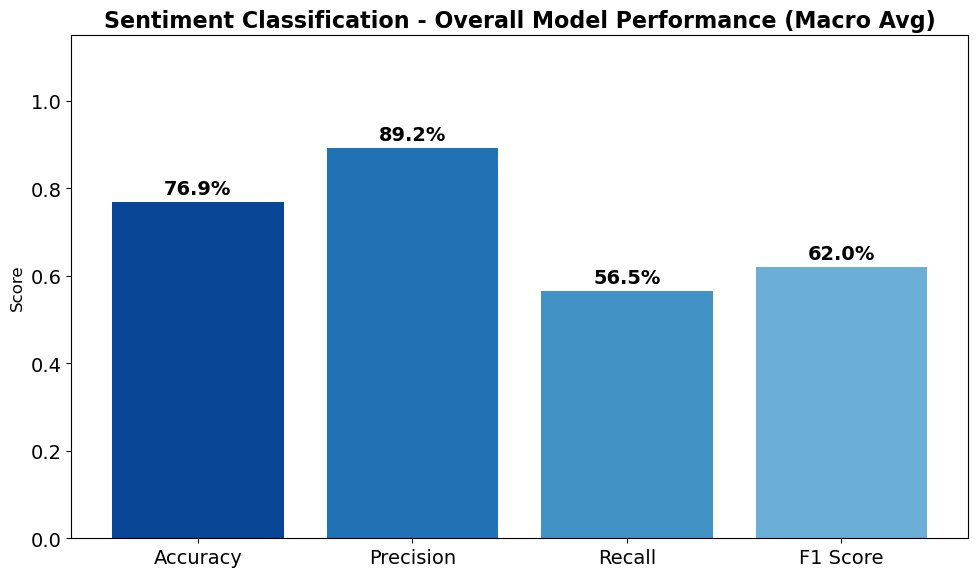

In [12]:
# Classification Report with Bar Plot Visualization
report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True, zero_division=0)

# Extract overall metrics
metrics = {
    'Accuracy': report['accuracy'],
    'Precision': report['macro avg']['precision'],
    'Recall': report['macro avg']['recall'],
    'F1 Score': report['macro avg']['f1-score']
}

# Prepare plot
names = list(metrics.keys())
values = list(metrics.values())

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar plot
colors = ['#084594', '#2171b5', '#4292c6', '#6baed6']
bars = ax.bar(names, values, color=colors)

# Add labels and formatting
ax.set_title('Sentiment Classification - Overall Model Performance (Macro Avg)', fontsize=16, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.1%}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Class-wise Performance
Grouped bar plot showing precision, recall, and F1 score for top sentiment classes.

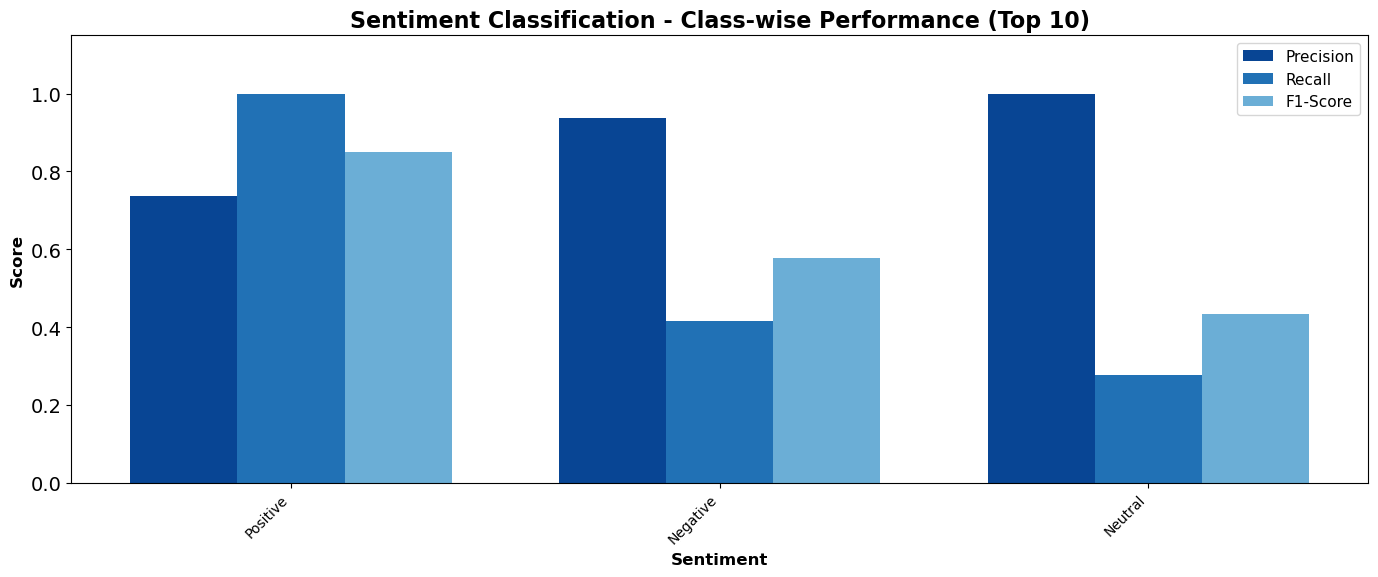

In [13]:
# Class-wise Precision, Recall and F1-Score (Top Classes)
top_n = min(10, len(target_names))  # Show top 10 classes

# Get top N classes by frequency
class_counts = pd.Series(y_test).value_counts()
top_class_indices = class_counts.head(top_n).index.tolist()
top_class_names = [target_names[i] for i in top_class_indices]

# Extract metrics for top classes
precision = [report[cls]['precision'] for cls in top_class_names]
recall = [report[cls]['recall'] for cls in top_class_names]
f1_scores = [report[cls]['f1-score'] for cls in top_class_names]

# Create grouped bar plot
x = np.arange(len(top_class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width, precision, width, label='Precision', color='#084594')
bars2 = ax.bar(x, recall, width, label='Recall', color='#2171b5')
bars3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='#6baed6')

ax.set_xlabel('Sentiment', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Sentiment Classification - Class-wise Performance (Top 10)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_class_names, fontsize=10, rotation=45, ha='right')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# F1 Score by Time Period
Calculate and visualize F1 scores aggregated by day, week, and month.

In [14]:
# F1 Score by Day, Week, and Month
# Create test results DataFrame with temporal info
test_df = df.loc[idx_test].copy()
test_df['predicted_label'] = y_pred
test_df['predicted_sentiment'] = label_encoder.inverse_transform(y_pred)
test_df['correct'] = (test_df['sentiment_label'] == test_df['predicted_label']).astype(int)

# Function to calculate F1 score for a group
def calc_f1(group):
    y_true = group['sentiment_label']
    y_pred = group['predicted_label']
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

# F1 by Day
f1_by_day = test_df.groupby('Date').apply(calc_f1).reset_index()
f1_by_day.columns = ['Date', 'F1_Score']
f1_by_day['Date'] = pd.to_datetime(f1_by_day['Date'])

# F1 by Week
f1_by_week = test_df.groupby(['Year', 'Week']).apply(calc_f1).reset_index()
f1_by_week.columns = ['Year', 'Week', 'F1_Score']
f1_by_week['Period'] = f1_by_week['Year'].astype(str) + '-W' + f1_by_week['Week'].astype(str).str.zfill(2)

# F1 by Month
f1_by_month = test_df.groupby(['Year', 'Month']).apply(calc_f1).reset_index()
f1_by_month.columns = ['Year', 'Month', 'F1_Score']
f1_by_month['Period'] = f1_by_month['Year'].astype(str) + '-' + f1_by_month['Month'].astype(str).str.zfill(2)

print("F1 Score by Day (first 10):")
print(f1_by_day.head(10))
print(f"\nF1 Score by Week (first 10):")
print(f1_by_week.head(10))
print(f"\nF1 Score by Month:")
print(f1_by_month)

F1 Score by Day (first 10):
        Date  F1_Score
0 2011-09-22       1.0
1 2013-04-20       1.0
2 2013-12-05       1.0
3 2015-09-28       1.0
4 2015-11-08       1.0
5 2015-11-10       1.0
6 2015-12-18       1.0
7 2016-04-10       1.0
8 2016-04-15       1.0
9 2016-05-15       1.0

F1 Score by Week (first 10):
   Year  Week  F1_Score    Period
0  2011    38       1.0  2011-W38
1  2013    16       1.0  2013-W16
2  2013    49       1.0  2013-W49
3  2015    40       1.0  2015-W40
4  2015    45       1.0  2015-W45
5  2015    46       1.0  2015-W46
6  2015    51       1.0  2015-W51
7  2016    14       1.0  2016-W14
8  2016    15       1.0  2016-W15
9  2016    19       1.0  2016-W19

F1 Score by Month:
    Year  Month  F1_Score   Period
0   2011      9  1.000000  2011-09
1   2013      4  1.000000  2013-04
2   2013     12  1.000000  2013-12
3   2015      9  1.000000  2015-09
4   2015     11  1.000000  2015-11
..   ...    ...       ...      ...
61  2023      6  0.461538  2023-06
62  2023      7

# F1 Score Temporal Visualizations
Line plots showing F1 score trends over time.

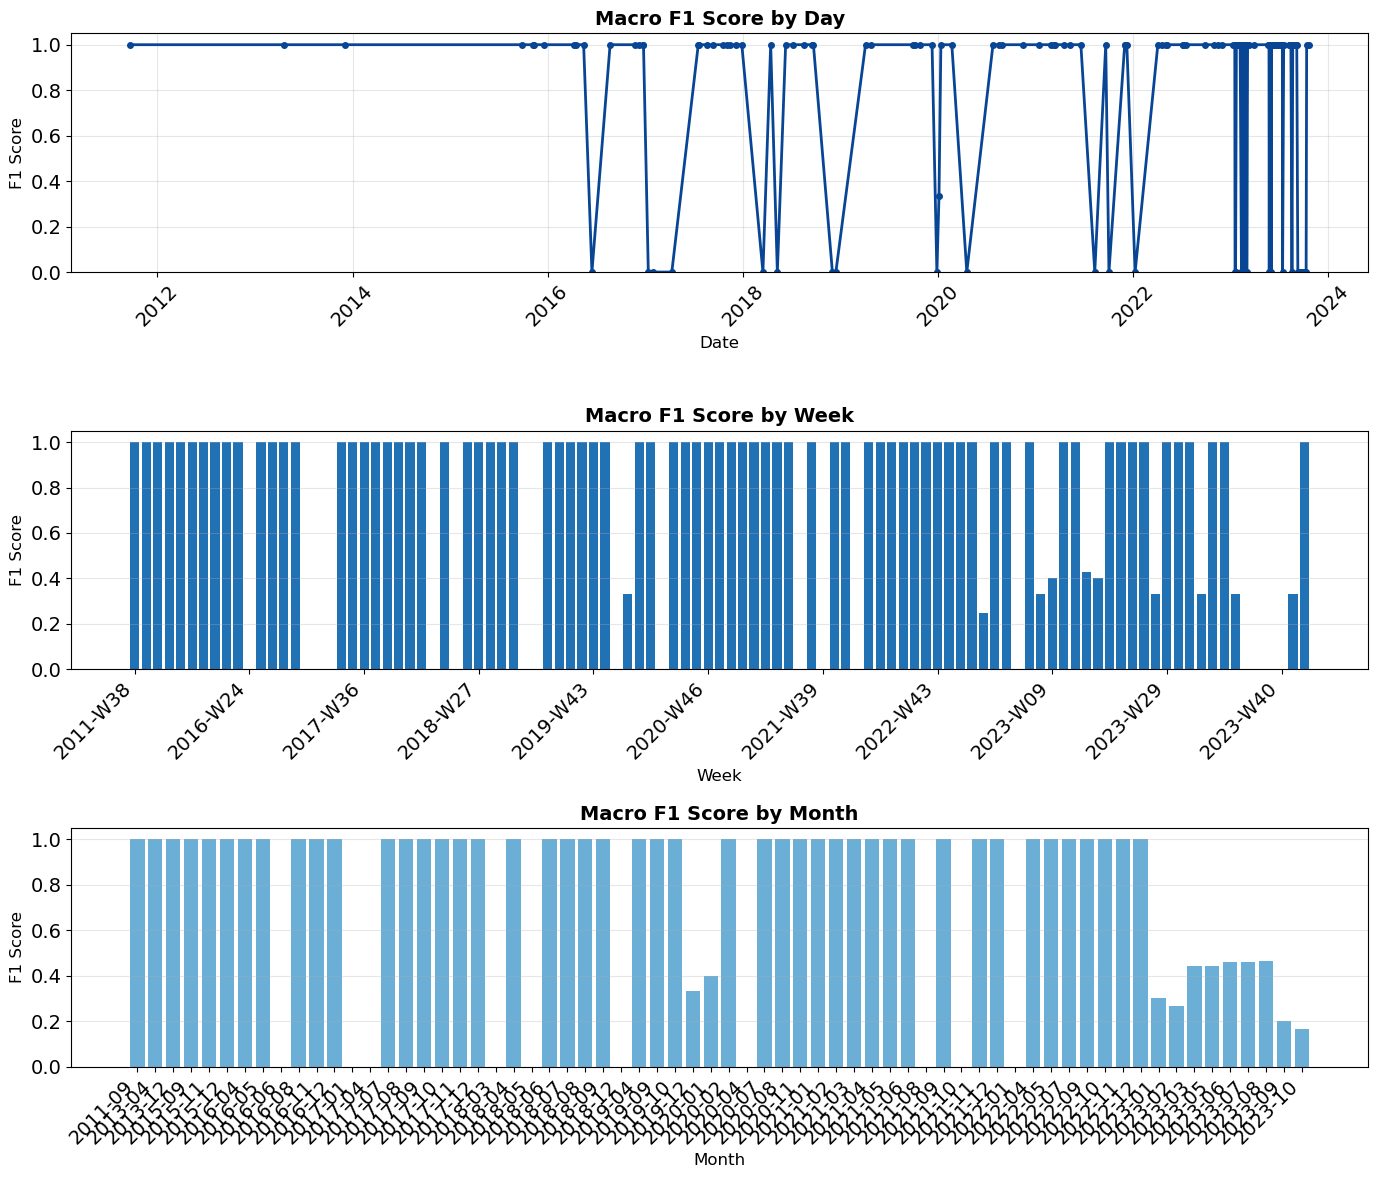

In [15]:
# F1 Score Temporal Visualizations
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# F1 by Day
ax1 = axes[0]
ax1.plot(f1_by_day['Date'], f1_by_day['F1_Score'], marker='o', color='#084594', linewidth=2, markersize=4)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('F1 Score', fontsize=12)
ax1.set_title('Macro F1 Score by Day', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# F1 by Week
ax2 = axes[1]
ax2.bar(range(len(f1_by_week)), f1_by_week['F1_Score'], color='#2171b5')
ax2.set_xlabel('Week', fontsize=12)
ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_title('Macro F1 Score by Week', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1.05)
# Show subset of x-tick labels for readability
tick_step = max(1, len(f1_by_week) // 10)
ax2.set_xticks(range(0, len(f1_by_week), tick_step))
ax2.set_xticklabels(f1_by_week['Period'].iloc[::tick_step], rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

# F1 by Month
ax3 = axes[2]
ax3.bar(range(len(f1_by_month)), f1_by_month['F1_Score'], color='#6baed6')
ax3.set_xlabel('Month', fontsize=12)
ax3.set_ylabel('F1 Score', fontsize=12)
ax3.set_title('Macro F1 Score by Month', fontsize=14, fontweight='bold')
ax3.set_ylim(0, 1.05)
ax3.set_xticks(range(len(f1_by_month)))
ax3.set_xticklabels(f1_by_month['Period'], rotation=45, ha='right')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# F1 Score Over Time - Line Chart
Single line chart showing F1 score trend over time (by month).

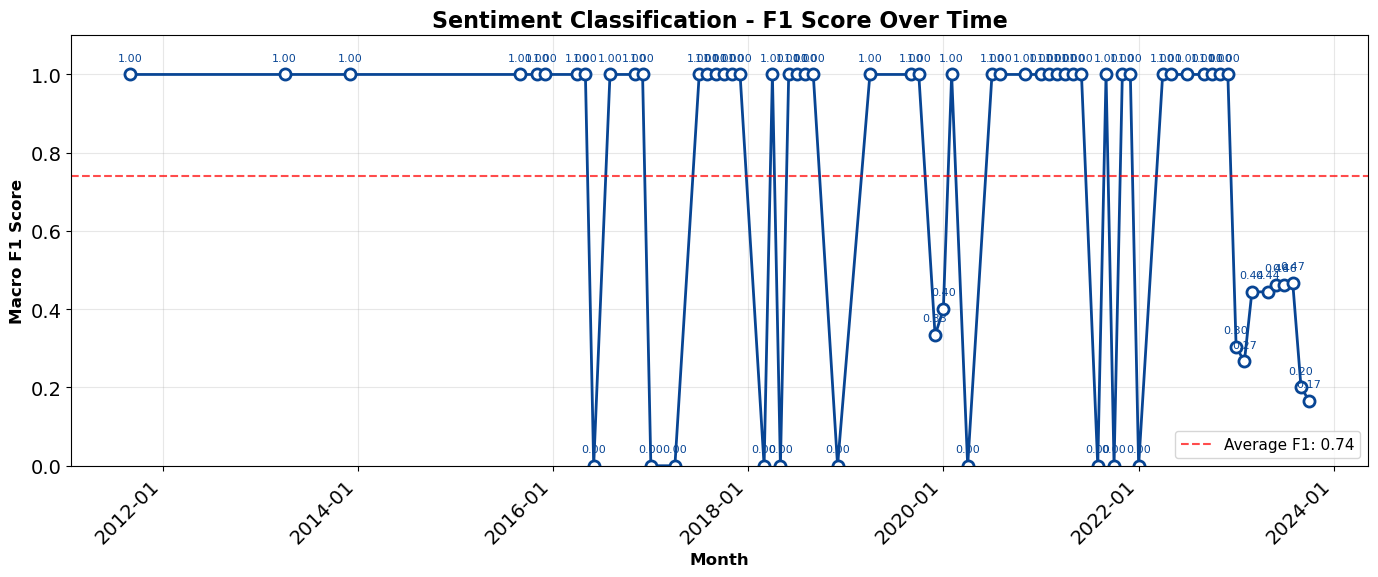


Average F1 Score: 0.7416


In [16]:
# F1 Score Over Time - Line Chart (Monthly)
fig, ax = plt.subplots(figsize=(14, 6))

# Convert Period to datetime for proper x-axis ordering
f1_by_month['Date'] = pd.to_datetime(f1_by_month['Period'] + '-01')
f1_by_month_sorted = f1_by_month.sort_values('Date')

# Plot line chart
ax.plot(f1_by_month_sorted['Date'], f1_by_month_sorted['F1_Score'], 
        marker='o', color='#084594', linewidth=2, markersize=8, 
        markerfacecolor='white', markeredgewidth=2)

# Add data labels
for i, row in f1_by_month_sorted.iterrows():
    ax.annotate(f'{row["F1_Score"]:.2f}', 
                (row['Date'], row['F1_Score']),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=8, color='#084594')

# Formatting
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Macro F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Sentiment Classification - F1 Score Over Time', fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)

# Format x-axis dates
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')

# Add horizontal line for average F1
avg_f1 = f1_by_month_sorted['F1_Score'].mean()
ax.axhline(y=avg_f1, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Average F1: {avg_f1:.2f}')
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nAverage F1 Score: {avg_f1:.4f}")

# Save Results for Power BI
Export test results and F1 metrics to CSV files for visualization in Power BI.

In [17]:
# Save Test Results with Predictions
test_results = test_df[['Text', 'Sentiment', 'predicted_sentiment', 'sentiment_label', 'predicted_label',
                        'Timestamp', 'Date', 'Year', 'Month', 'Week', 'Day', 'Platform', 'Country']].copy()
test_results.columns = ['Text', 'actual_sentiment', 'predicted_sentiment', 'actual_label', 'predicted_label',
                        'Timestamp', 'Date', 'Year', 'Month', 'Week', 'Day', 'Platform', 'Country']
test_results['is_correct'] = (test_results['actual_label'] == test_results['predicted_label']).astype(int)

# Save main results
test_results.to_csv('sentiment_test_results.csv', index=False)
print(f"Test results saved to 'sentiment_test_results.csv'")
print(f"Shape: {test_results.shape}")

# Save F1 by Day
f1_by_day.to_csv('sentiment_f1_by_day.csv', index=False)
print(f"\nF1 by Day saved to 'sentiment_f1_by_day.csv'")

# Save F1 by Week
f1_by_week.to_csv('sentiment_f1_by_week.csv', index=False)
print(f"F1 by Week saved to 'sentiment_f1_by_week.csv'")

# Save F1 by Month
f1_by_month.to_csv('sentiment_f1_by_month.csv', index=False)
print(f"F1 by Month saved to 'sentiment_f1_by_month.csv'")

# Save confusion matrix in long format for Power BI
cm_data = []
for i, actual in enumerate(target_names):
    for j, predicted in enumerate(target_names):
        cm_data.append({'actual_sentiment': actual, 'predicted_sentiment': predicted, 'count': cm[i][j]})
cm_df = pd.DataFrame(cm_data)
cm_df.to_csv('sentiment_confusion_matrix.csv', index=False)
print(f"\nConfusion matrix saved to 'sentiment_confusion_matrix.csv'")

print("\n" + "="*50)
print("All files saved successfully for Power BI import!")

Test results saved to 'sentiment_test_results.csv'
Shape: (147, 14)

F1 by Day saved to 'sentiment_f1_by_day.csv'
F1 by Week saved to 'sentiment_f1_by_week.csv'
F1 by Month saved to 'sentiment_f1_by_month.csv'

Confusion matrix saved to 'sentiment_confusion_matrix.csv'

All files saved successfully for Power BI import!


In [19]:
# Preview saved data
print("Preview of test results:")
test_results.head(10)

Preview of test results:


,Text,actual_sentiment,predicted_sentiment,actual_label,predicted_label,Timestamp,Date,Year,Month,Week,Day,Platform,Country,is_correct
707,Experimenting with a new recipe for a school b...,Neutral,Positive,1,2,2023-10-05 14:15:00,2023-10-05,2023,10,40,5,Instagram,USA,0
195,"Boredom lingers, a stagnant pool of indiffere...",Neutral,Positive,1,2,2021-10-02 19:00:00,2021-10-02,2021,10,39,2,Facebook,Canada,0
351,Excitement builds while preparing for a surpri...,Positive,Positive,2,2,2023-03-05 15:00:00,2023-03-05,2023,3,9,5,Facebook,Australia,1
585,"Got dressed for the day, then remembered it's ...",Neutral,Positive,1,2,2023-05-25 19:00:00,2023-05-25,2023,5,21,25,Facebook,USA,0
24,Celebrating a milestone at work! 🎉 ...,Positive,Positive,2,2,2023-01-22 14:30:00,2023-01-22,2023,1,3,22,Facebook,Canada,1
431,"Painful echoes of a love once cherished, now l...",Negative,Negative,0,0,2016-11-22 09:45:00,2016-11-22,2016,11,47,22,Facebook,Netherlands,1
203,"Embracing the ebb and flow of life, finding a...",Positive,Positive,2,2,2023-01-10 16:20:00,2023-01-10,2023,1,2,10,Instagram,UK,1
44,Exploring local art galleries this weekend. ...,Positive,Positive,2,2,2023-01-30 11:30:00,2023-01-30,2023,1,5,30,Facebook,USA,1
630,"Participated in a local theater production, pr...",Positive,Positive,2,2,2023-07-09 22:30:00,2023-07-09,2023,7,27,9,Facebook,USA,1
156,Compassion in volunteering for a local charit...,Positive,Positive,2,2,2015-12-18 14:20:00,2015-12-18,2015,12,51,18,Facebook,USA,1
